# 04 · Train CBAM-ConvNeXt (proposed)
Thin driver over the shared engine — the ONLY difference between 02/03/04 is the model key.

In [31]:
# === Preamble 1/2: environment & GPU report ===
# This is a REMOTE Colab kernel — it cannot see your local files.
import sys
print('Python:', sys.version.split()[0])
try:
    import torch
    print('PyTorch:', torch.__version__, '| CUDA:', torch.cuda.is_available())
    if torch.cuda.is_available():
        print('GPU:', torch.cuda.get_device_name(0))
        print('bfloat16 supported:', torch.cuda.is_bf16_supported())
    else:
        print('No GPU — Runtime > Change runtime type > A100 (or L4).')
except ImportError:
    print('torch installs in the next cell.')

Python: 3.12.13
PyTorch: 2.11.0+cu128 | CUDA: True
GPU: NVIDIA A100-SXM4-40GB
bfloat16 supported: True


In [32]:
# === Preamble 2/2: clone-or-pull + install (+ optional autoreload) ===
import os, subprocess, sys

REPO_URL = "https://github.com/Kidhurshan/plant-leaf-classifier.git"  # <-- EDIT to your repo
REPO_DIR = "/content/plant-leaf-classifier"
# Private repo? use https://<TOKEN>@github.com/Kidhurshan/plant-leaf-classifier.git

if not os.path.isdir(REPO_DIR):
    print('Cloning', REPO_URL)
    subprocess.run(['git', 'clone', REPO_URL, REPO_DIR], check=True)
os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r',
                'requirements.txt'], check=True)

# Hot-reload src/ after a `git pull` (optional convenience; never fatal).
try:
    from IPython import get_ipython
    _ip = get_ipython()
    _ip.run_line_magic('load_ext', 'autoreload')
    _ip.run_line_magic('autoreload', '2')
    print('autoreload enabled.')
except Exception as _e:
    print('autoreload not enabled (non-fatal):', repr(_e))

from src.utils import sync_repo, gpu_report
sync_repo()   # git pull + print the commit hash these results are traceable to
gpu_report()

autoreload not enabled (non-fatal): ModuleNotFoundError("No module named 'imp'")
Syncing repository (git pull)...
Already up to date.
Now running code at commit: e490cfd [DIRTY WORKING TREE]
ENVIRONMENT
  Python        : 3.12.13
  PyTorch       : 2.11.0+cu128
  CUDA available: True
  GPU           : NVIDIA A100-SXM4-40GB
  VRAM          : 39.5 GB
  CUDA runtime  : 12.8
  bfloat16      : YES


{'python': '3.12.13',
 'torch': '2.11.0+cu128',
 'cuda_available': True,
 'gpu': 'NVIDIA A100-SXM4-40GB',
 'vram_gb': 39.5,
 'cuda_version': '12.8',
 'bf16_supported': True}

## Why this architecture
**CBAM-ConvNeXt (proposed)** takes a modern CNN (ConvNeXt-Tiny — a ResNet modernised with large kernels, LayerNorm and GELU) and inserts **CBAM** attention after its later stages. CBAM applies channel- then spatial-attention gates so the network emphasises the most discriminative leaf regions; it is identity-initialised so pretrained features survive the first step.

## Config, model summary & shape check

In [33]:
from src.config import load_config
from src.utils import set_seed, detect_amp
from src.models import build_model, describe_model
import torch

SMOKE = False   # True -> ~200 imgs, 1+1 epochs, <5 min (needs nb 01 smoke cache)
MODEL = 'cbam_convnext'
cfg = load_config('configs/default.yaml')
cfg.paths.ensure_dirs()
set_seed(cfg.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

_m = build_model(cfg, MODEL, device=device)
print(describe_model(_m))
with torch.no_grad():
    _o = _m(torch.randn(2, 3, cfg.data.img_size, cfg.data.img_size, device=device))
assert tuple(_o.shape) == (2, cfg.data.num_classes), _o.shape
print('shape check OK:', tuple(_o.shape))
del _m  # train_model builds its own fresh copy

01:58:01 | WARNING | Stage-hook CBAM failed ('list' object has no attribute 'channels'); using final-map CBAM.
01:58:01 | INFO    | CBAM attached to final feature map (768 ch).
01:58:01 | INFO    | Built 'cbam_convnext' (backbone=convnext_tiny.fb_in22k_ft_in1k, cbam=True): 27.9M params (27.9M trainable).
Backbone      : convnext_tiny.fb_in22k_ft_in1k
CBAM          : True (1 module(s))
Feature dim   : 768
Total params  : 27,902,460 (27.9M)
Trainable     : 27,902,460 (27.9M)
Top-level modules:
  - backbone       ConvNeXt                27.8M params
  - cbam_modules   ModuleList              74.6K params
  - _cbam_final    CBAM                    74.6K params
  - head           SharedHead               7.7K params
shape check OK: (2, 8)


## Preview one augmented image

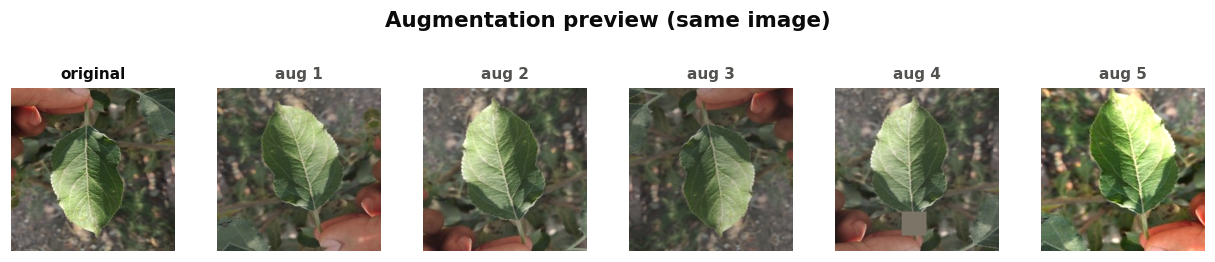

In [34]:
from src.data import prepare_datasets
from src.augment import GPUAugment, denormalize
from src import viz
datasets, class_names = prepare_datasets(cfg, device, smoke=SMOKE)
aug = GPUAugment(cfg.augment, cfg.data.img_size, device, training=True)
one = datasets['train'].images[datasets['train'].indices[0]].unsqueeze(0)
viz.plot_augmentation_preview(viz.to_hwc_uint8(one[0]),
                              [denormalize(aug(one))[0] for _ in range(5)]);

## Train — phase 1 (frozen backbone) then phase 2 (fine-tune all)
Watch the live per-epoch log; a total-runtime estimate prints after epoch 1.

In [35]:
from src.engine import train_model
res = train_model(cfg, MODEL, datasets, device, smoke=SMOKE,
                  class_names=class_names)
print('Best val macro-F1:', round(res['best_val_macro_f1'], 4))

01:58:15 | WARNING | Stage-hook CBAM failed ('list' object has no attribute 'channels'); using final-map CBAM.
01:58:15 | INFO    | CBAM attached to final feature map (768 ch).
01:58:15 | INFO    | Built 'cbam_convnext' (backbone=convnext_tiny.fb_in22k_ft_in1k, cbam=True): 27.9M params (27.9M trainable).
01:58:15 | INFO    | Train class counts: [363, 238, 356, 364, 383, 328, 369, 111]

=== cbam_convnext: PHASE 1 (frozen backbone, 5 epochs) ===
  [P1 E01] train_loss=0.2334 val_loss=0.0046 val_acc=0.9963 val_f1=0.9962 lr=1.00e-03 (37.8s)
    * new best macro-F1=0.9962 -> saved cbam_convnext_best.pt
  >> Estimated total training time: ~25m 10s (40 planned epochs @ 37.8s/epoch).
  [P1 E02] train_loss=0.0064 val_loss=0.0015 val_acc=1.0000 val_f1=1.0000 lr=1.00e-03 (1.0s)
    * new best macro-F1=1.0000 -> saved cbam_convnext_best.pt
  [P1 E03] train_loss=0.0034 val_loss=0.0014 val_acc=0.9981 val_f1=0.9979 lr=1.00e-03 (1.0s)
  [P1 E04] train_loss=0.0029 val_loss=0.0008 val_acc=1.0000 val_f1=1

## Training curves (visual 4)

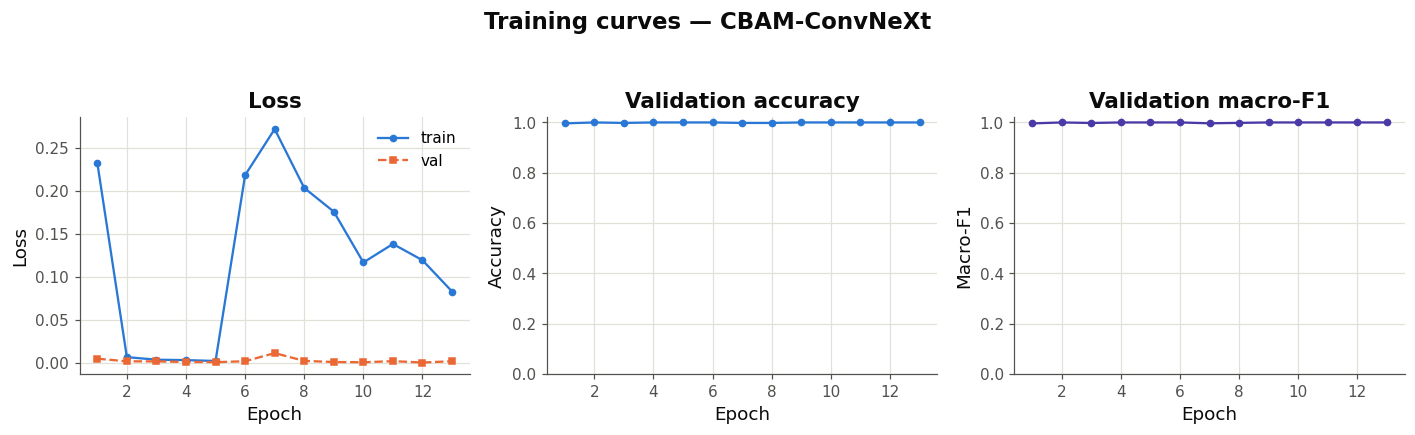

In [36]:
viz.plot_training_curves(res['history'], MODEL,
    out_path=f"{cfg.paths.figures_dir}/{MODEL}_curves.png");

## Validation confusion matrix

02:00:05 | INFO    | Eval: acc=1.0000 macro-F1=1.0000
              precision    recall  f1-score   support

       apple     1.0000    1.0000    1.0000        78
       berry     1.0000    1.0000    1.0000        51
         fig     1.0000    1.0000    1.0000        76
       guava     1.0000    1.0000    1.0000        78
      orange     1.0000    1.0000    1.0000        82
        palm     1.0000    1.0000    1.0000        70
   persimmon     1.0000    1.0000    1.0000        79
      tomato     1.0000    1.0000    1.0000        24

    accuracy                         1.0000       538
   macro avg     1.0000    1.0000    1.0000       538
weighted avg     1.0000    1.0000    1.0000       538



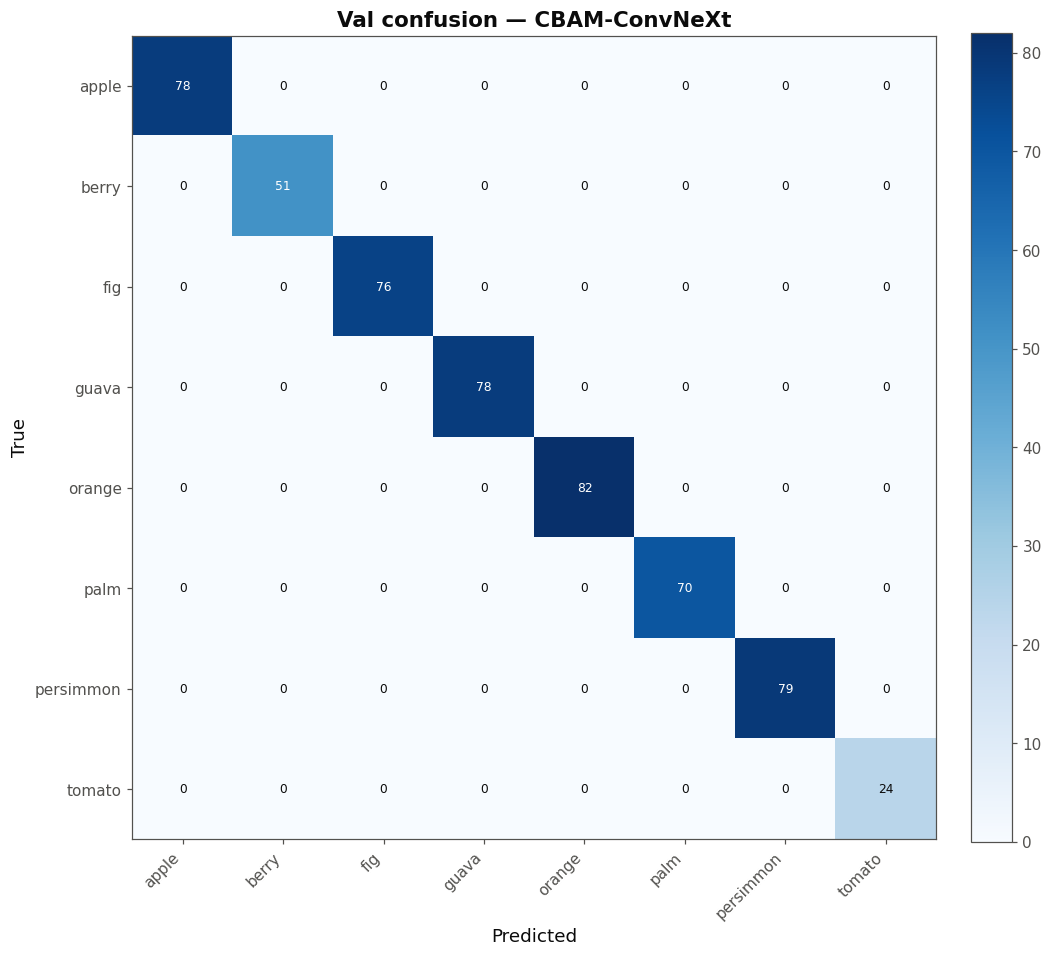

In [37]:
from src.evaluate import evaluate_model
from src.utils import detect_amp
aug_eval = GPUAugment(cfg.augment, cfg.data.img_size, device, training=False)
bs = cfg.smoke.batch_size if SMOKE else cfg.train.batch_size
m = evaluate_model(res['model'], datasets['val'], aug_eval,
                   detect_amp(device), bs, class_names)
viz.plot_confusion_matrix(m['confusion_matrix'], class_names,
    out_path=f"{cfg.paths.figures_dir}/{MODEL}_val_confusion.png",
    title=f'Val confusion — {viz.display_name(MODEL)}')
print(m['report'])

## Outputs

In [38]:
print('checkpoint ->', res['best_checkpoint'])
print('history    ->', res['history_csv'])
print('figures    ->', cfg.paths.figures_dir)

checkpoint -> checkpoints/cbam_convnext_best.pt
history    -> results/metrics/cbam_convnext_history.csv
figures    -> results/figures


---
### ⚠️ When finished: disconnect and DELETE the runtime
`Runtime > Disconnect and delete runtime`. Colab compute units are consumed the whole time a runtime is connected.